In [ ]:
import numpy as np
import shutil
from google.colab import drive
shutil.rmtree('/content/drive', ignore_errors=True)
drive.mount('/content/drive')
!ls /content/drive/MyDrive/corneal_ulcer_dataset/

Mounted at /content/drive
'Category information.xlsx'   test_images.npy	 ulcerOverlay
 corneaLabels		      test_ulcer.npy	 val_cornea.npy
 corneaOverlay		      train_cornea.npy	 val_images.npy
 rawImages		      train_images.npy	 val_ulcer.npy
 synthetic_training	      train_ulcer.npy
 test_cornea.npy	      ulcerLabels


In [ ]:
!ls "/content/drive/MyDrive/corneal_ulcer_dataset/"

'Category information.xlsx'   test_images.npy	 ulcerLabels
 corneaLabels		      test_ulcer.npy	 ulcerOverlay
 corneaOverlay		      train_cornea.npy	 val_cornea.npy
 rawImages		      train_images.npy	 val_images.npy
 test_cornea.npy	      train_ulcer.npy	 val_ulcer.npy


In [ ]:
import numpy as np
train_images = np.load("/content/drive/MyDrive/corneal_ulcer_dataset/train_images.npy")
train_cornea = np.load("/content/drive/MyDrive/corneal_ulcer_dataset/train_cornea.npy")
train_ulcer = np.load("/content/drive/MyDrive/corneal_ulcer_dataset/train_ulcer.npy")

In [ ]:
import cv2
import numpy as np
import os
from scipy.ndimage import gaussian_filter
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import torch

basePath = "/content/drive/MyDrive/corneal_ulcer_dataset/"
mask_save_path = os.path.join(basePath, "synthetic_training/test_masks/")
os.makedirs(mask_save_path, exist_ok=True)
vlm_save_path  = os.path.join(basePath, "synthetic_training/test_vlm_images/")
os.makedirs(vlm_save_path, exist_ok=True)
os.makedirs(mask_save_path, exist_ok=True)
os.makedirs(vlm_save_path, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

#Using ControlNet
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/control_v11p_sd15_seg", torch_dtype=torch.float16
)
pipe = StableDiffusionControlNetPipeline.from_pretrained("runwayml/stable-diffusion-v1-5",controlnet=controlnet,safety_checker=None,torch_dtype=torch.float16).to(device)

#Elastic transform function
def elastic_transform(mask, alpha=40, sigma=6):

  random_state = np.random.RandomState(None)
  shape = mask.shape
  dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
  dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
  x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
  map_x = (x + dx).astype(np.float32)
  map_y = (y + dy).astype(np.float32)
  return cv2.remap(mask.astype(np.uint8), map_x, map_y, interpolation=cv2.INTER_NEAREST)

#Function to generate VLM image
def generate_synthetic_from_mask(mask_path, output_path):

  mask = Image.open(mask_path).convert("RGB").resize((512, 512))
  prompt = (
        "high resolution slit-lamp anterior eye photograph showing corneal ulcer "
        "at the highlighted area. medical imaging, realistic corneal texture, "
        "no artifacts, fluorescein staining, cobalt blue illumination"
    )
  result = pipe(prompt, image=mask, num_inference_steps=40)
  out = result.images[0]
  out.save(output_path)

#Process first 5 masks from train_ulcer
for idx, m in enumerate(train_ulcer[:5]):
    #Elastic transform
    new_mask = elastic_transform(m)
    new_mask = cv2.resize(new_mask, (256, 256))
    new_mask = (new_mask > 0.5).astype(np.uint8) * 255

    mask_file = os.path.join(mask_save_path, f"mask_{idx}.png")
    cv2.imwrite(mask_file, new_mask)

    #Generate synthetic image from this mask
    vlm_file = os.path.join(vlm_save_path, f"img_{idx}.png")
    generate_synthetic_from_mask(mask_file, vlm_file)

    print(f"Saved mask + image pair {idx}")

print("Done generating test pairs!")


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/40 [00:00<?, ?it/s]

Saved mask + image pair 0


  0%|          | 0/40 [00:00<?, ?it/s]

...

Saved mask + image pair 2


  0%|          | 0/40 [00:00<?, ?it/s]

Saved mask + image pair 3


  0%|          | 0/40 [00:00<?, ?it/s]

Saved mask + image pair 4
Done generating test pairs!


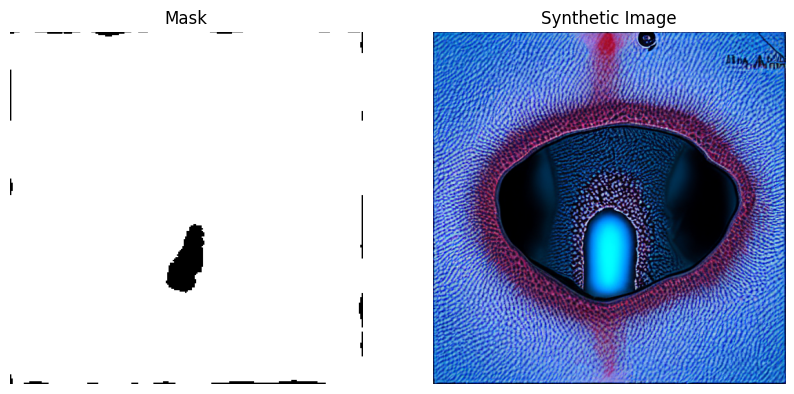

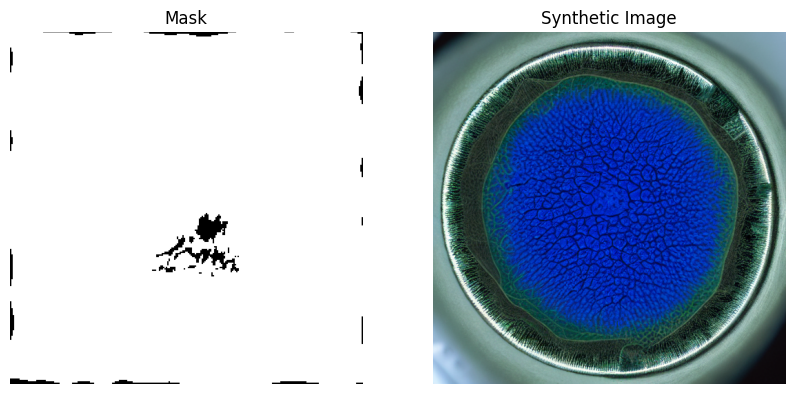

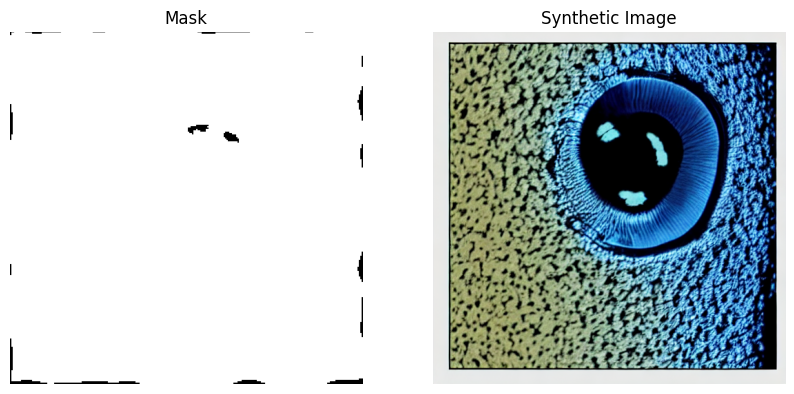

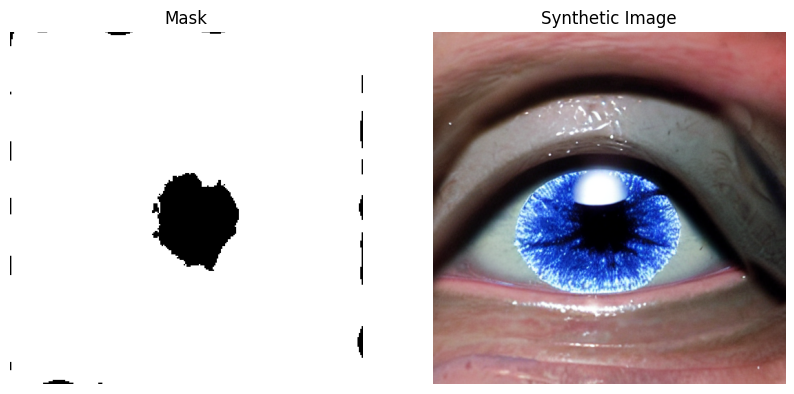

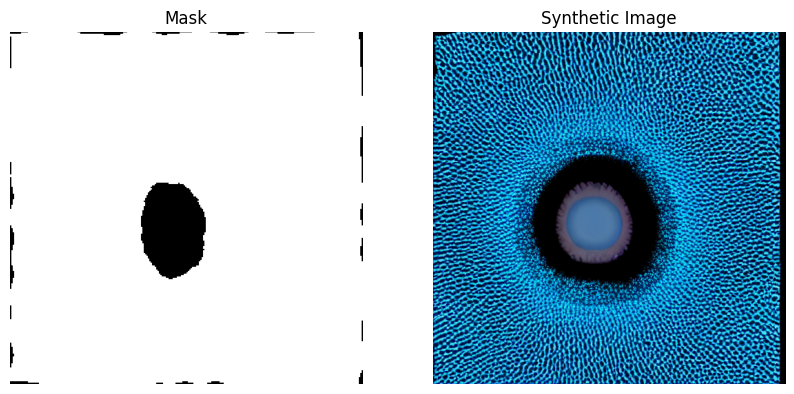

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

# Paths
mask_folder = mask_save_path
image_folder = vlm_save_path

# Get sorted list of files
mask_files = sorted([f for f in os.listdir(mask_folder) if f.endswith(".png")])
image_files = sorted([f for f in os.listdir(image_folder) if f.endswith(".png")])

# Visualize all pairs
for m_file, i_file in zip(mask_files, image_files):
    mask = cv2.imread(os.path.join(mask_folder, m_file), cv2.IMREAD_GRAYSCALE)
    img  = cv2.imread(os.path.join(image_folder, i_file))
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR to RGB for matplotlib

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img)
    plt.title("Synthetic Image")
    plt.axis('off')

    plt.show()


Elastic deformation is popular in segmentation training but for corneal ulcers it can produce rubbery blobs that don't match real ulcer morphology which then drives the generator into weird territory.

Stable diffusuon : was NOT trained on medical images so results look weird

